<a href="https://colab.research.google.com/github/davidsonclem/senai-quantum/blob/Master/08_algoritimos_quanticos/hands_on/02/algoritimos_quantico_atv02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# UNIVERSIDADE SENAI CIMATEC
# CURSO DE ESPECIALIZAÇÃO EM COMPUTAÇÃO QUÂNTICA

## Hands-On 02: Implementação do QAOA para o Problema do Caixeiro Viajante

### **Disciplina:** Algoritimos Quânticos

### **Turma:** 98895

### **Objetivos da Atividade**

* Implementar o algoritmo QAOA para resolução do problema do Caixeiro Viajante (TSP);
* Diferenciar o desempenho clássico e quântico quanto aos tamanhos de instância do TSP;
* Explicar as vantagens e limitações do QAOA em contextos práticos.

### **Conteúdo Formativo**

* TSP - Problema do Caixeiro Viajante;
* QAOA.

### **Dados da Atividade**

* **Professor:** Dr. Gustavo Arruda
* **Alunos/Equipe:**
    * Davidson Corrêa Clem
    * João Filipe Muchanga
    * José Hidalgo Suárez
    
* **Data:**  15/03/2026

---

## **Links para consultas:**

Github -> https://github.com/davidsonclem/senai-quantum/blob/Master/08_algoritimos_quanticos/hands_on/02/algoritimos_quantico_atv02.ipynb

# Resolução do Problema do Caixeiro Viajante (TSP)
**Estudo Comparativo: Força Bruta Clássica vs. Algoritmo Quântico QAOA**

Este notebook implementa a solução do TSP para uma instância de 4 cidades, comparando o tempo de execução e a rota encontrada entre um algoritmo clássico e o algoritmo quântico variacional QAOA.


Setup: baixa os módulos do GitHub e adiciona ao path do Colab

- Os arquivos são baixados direto do repositório do projeto.

## **Preparação do Ambiente**

Execute a célula abaixo **apenas se ainda não tiver** Qiskit instalado.

In [ ]:
# ==============================================================
# Baixa os módulos do GitHub e adiciona ao path do Colab
# ==============================================================
import subprocess, sys

REPO_RAW  = "https://raw.githubusercontent.com/davidsonclem/senai-quantum/Master"
BASE_PATH = "08_algoritimos_quanticos/hands_on/02"

MODULOS = [
    "config.py",
    "tsp_graph.py",
    "solvers.py",
    "visualization.py",
    "analysis.py",
]

for modulo in MODULOS:
    url  = f"{REPO_RAW}/{BASE_PATH}/{modulo}"
    dest = f"/content/{modulo}"
    subprocess.run(["wget", "-q", "-O", dest, url], check=True)
    print(f"✔ {modulo} baixado")

# Garante que /content está no path para os imports funcionarem
if "/content" not in sys.path:
    sys.path.insert(0, "/content")

print("\n✔ Todos os módulos prontos. Pode executar as próximas células.")

✔ config.py baixado
✔ tsp_graph.py baixado
✔ solvers.py baixado
✔ visualization.py baixado
✔ analysis.py baixado

✔ Todos os módulos prontos. Pode executar as próximas células.


### **Passo 1:** Instalações



In [ ]:
import importlib, subprocess, sys

_pkgs = [
    "qiskit", "qiskit-aer", "qiskit-optimization",
    "qiskit-algorithms", "docplex", "networkx", "matplotlib",
]
_missing = [p for p in _pkgs if importlib.util.find_spec(p.replace("-", "_")) is None]
if _missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q"] + _missing)
    print("✔ Pacotes instalados:", _missing)
else:
    print("✔ Todas as dependências já estão presentes.")

✔ Todas as dependências já estão presentes.


### **Passo 2:** Imports globais e supressão de warnings

In [ ]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)

print("✔ Imports e configurações prontos.")

✔ Imports e configurações prontos.


### **Passo 3:** Imports dos módulos

In [ ]:
from config        import INSTANCES
from tsp_graph     import build_qubo
from solvers       import solve_classical, solve_qaoa
from visualization import plot_graph, plot_route, plot_qaoa_probabilities
from analysis      import compare_results

print("✔ Módulos carregados.")

✔ Módulos carregados.


### **Passo 3:** Execução Quântica (QAOA)

Loop principal: roda todas as instâncias (w3, w4, w5, w6)
#
# ⚠️ Nota sobre desempenho no Colab:
#   O QAOA com StatevectorSampler simula 2^(n²) amplitudes por iteração.
#   w5 e w6 podem ser lentos ou estourar RAM — considere rodar apenas "3c"
#   e "4c" em ambientes com pouca memória (ver sugestões em config.py).


  INSTÂNCIA: 3 cidades (3c)


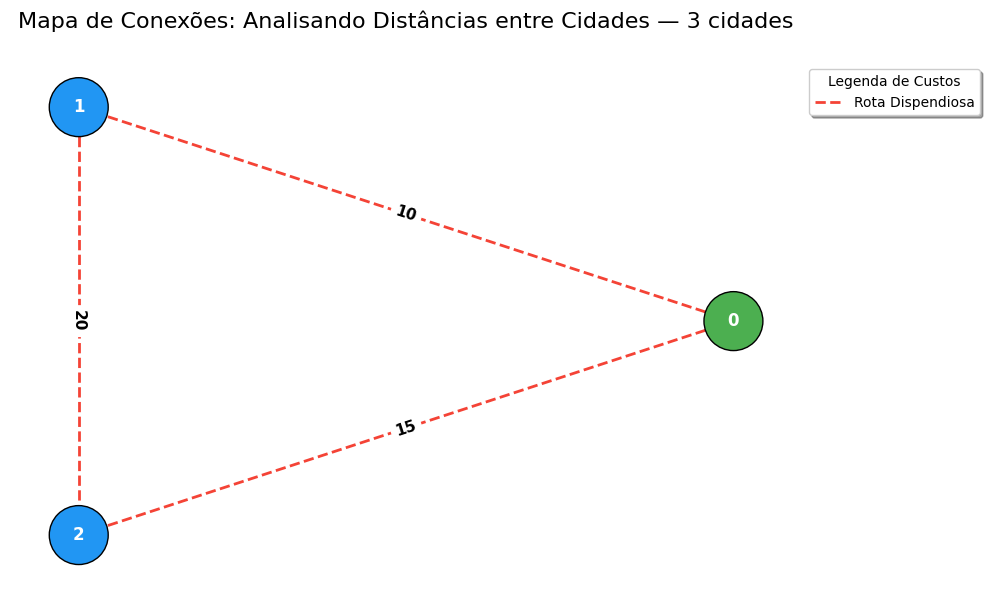

Rota Clássica: [1, 2, 0]  |  Tempo: 0.0316 s


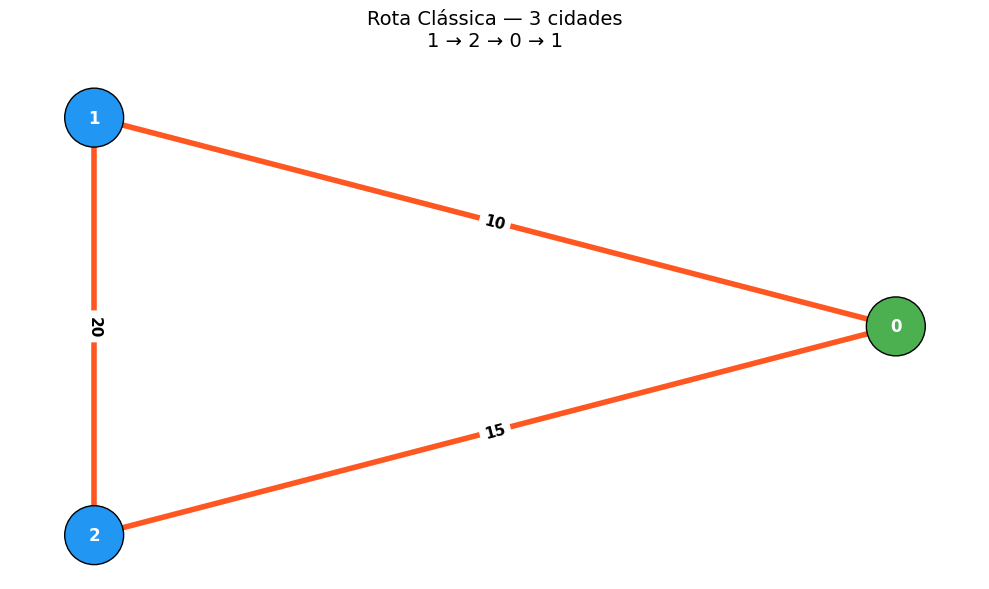

--- Iniciando QAOA (aguarde...) ---


/usr/local/lib/python3.12/dist-packages/scipy/sparse/linalg/_dsolve/linsolve.py:606: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
/usr/local/lib/python3.12/dist-packages/scipy/sparse/linalg/_matfuncs.py:707: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  return spsolve(Q, P)
/usr/local/lib/python3.12/dist-packages/scipy/sparse/_index.py:168: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])


Rota QAOA:     [1, 2, 0]  |  Tempo: 162.4904 s


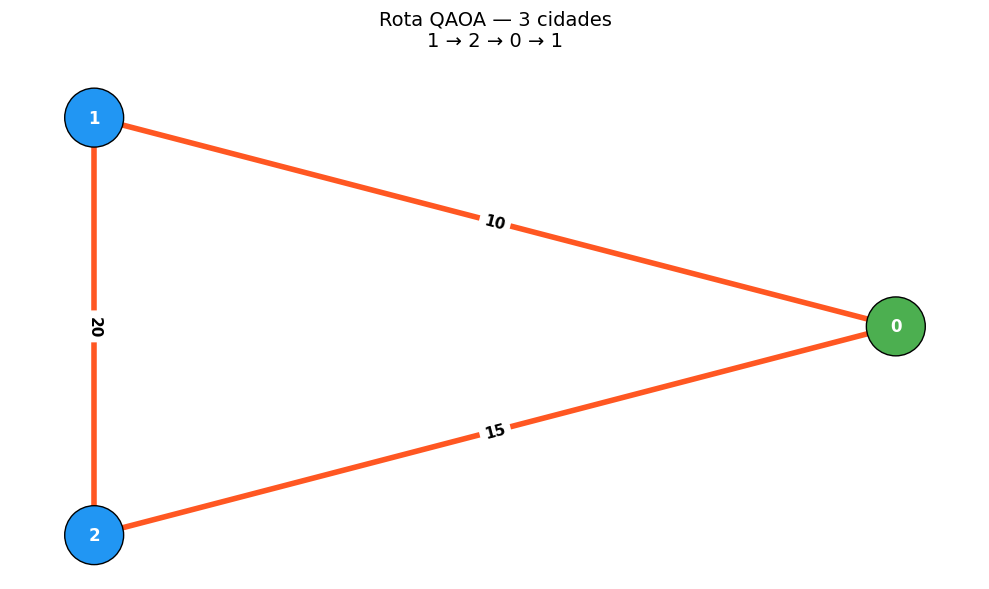

<Figure size 640x480 with 0 Axes>

        COMPARATIVO FINAL: Clássico vs. QAOA
Método               Rota                      Tempo (s)
-------------------------------------------------------
Solver Clássico      1 → 2 → 0 → 1             0.0316
QAOA                 1 → 2 → 0 → 1             162.4904

✔ Rotas equivalentes? Sim ✅

Conclusão: O QAOA encontrou a mesma solução ótima com abordagem probabilística,
enquanto o solver clássico garantiu o ótimo por enumeração exata do espaço de estados.

  INSTÂNCIA: 4 cidades (4c)


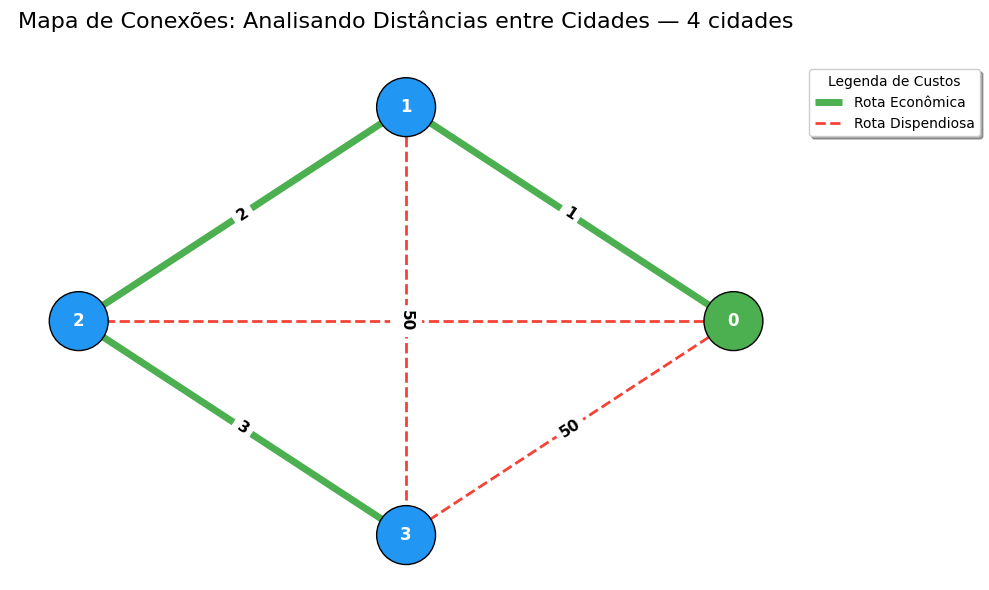

Rota Clássica: [3, 2, 1, 0]  |  Tempo: 1.1944 s


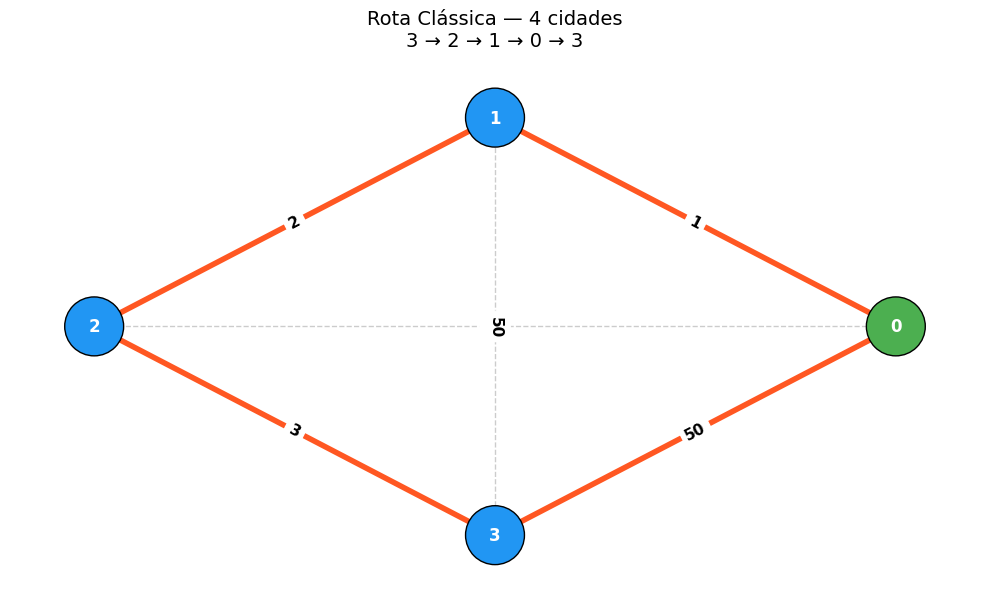

--- Iniciando QAOA (aguarde...) ---


/usr/local/lib/python3.12/dist-packages/scipy/sparse/linalg/_dsolve/linsolve.py:606: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
/usr/local/lib/python3.12/dist-packages/scipy/sparse/linalg/_matfuncs.py:707: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  return spsolve(Q, P)
/usr/local/lib/python3.12/dist-packages/scipy/sparse/_index.py:168: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])


In [ ]:
for chave, instancia in INSTANCES.items():
    w     = instancia["matrix"]
    label = instancia["label"]

    print("\n" + "=" * 55)
    print(f"  INSTÂNCIA: {label} ({chave})")
    print("=" * 55)

    # Visualização do grafo
    plot_graph(w, title_suffix=label)

    # Conversão para QUBO
    tsp_problem, qubo = build_qubo(w)

    # Solver clássico
    result_classic, t_classic = solve_classical(qubo)
    route_classic = tsp_problem.interpret(result_classic.x)
    print(f"Rota Clássica: {route_classic}  |  Tempo: {t_classic:.4f} s")
    plot_route(w, route_classic, title=f"Rota Clássica — {label}")

    # Solver quântico (QAOA)
    print("--- Iniciando QAOA (aguarde...) ---")
    result_qaoa, t_qaoa = solve_qaoa(qubo)
    route_qaoa = tsp_problem.interpret(result_qaoa.x)
    print(f"Rota QAOA:     {route_qaoa}  |  Tempo: {t_qaoa:.4f} s")
    plot_route(w, route_qaoa, title=f"Rota QAOA — {label}")

    # Probabilidades e comparativo
    plot_qaoa_probabilities(result_qaoa)
    compare_results(route_classic, t_classic, route_qaoa, t_qaoa)
